# Replay Simulation

Load a checkpoint (weights + initial state + normalizer) and roll the policy forward for `N_SIM_STEPS` (default 2000), tracking **every agent in every batch** at every step.

Outputs are written to `../simulated_run/{run_name}_from_step{S}/`:
- `sim_data_{N}steps.npz` — `data` shape `(n_steps, batch, agent, n_vars)`
- `meta.pkl` — variable names + source-checkpoint metadata

In [1]:
import sys
sys.path.insert(0, '..')

import os
import glob
import pickle
from datetime import datetime

import numpy as np
import torch
from tqdm.auto import tqdm

from src.utils.configloader import load_configs, dict_to_namespace
from src.environment import EconomyEnv
from src.normalizer import HardNormalizer, RunningPerAgentWelford
from src.models.model import FiLMResNet2In
from src.env_state import MainState

device = (
    torch.device('cuda') if torch.cuda.is_available()
    else torch.device('mps') if torch.backends.mps.is_available()
    else torch.device('cpu')
)
print(f'device: {device}')

device: mps


/opt/miniconda3/envs/sml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── CONFIG ───────────────────────────────────────────────────────────────────
CHECKPOINT_DIR = '../checkpoints/Bewley_Hetero_ability_high_uncer_nonlinear_HardNorm-focal'
CONFIG_PATH    = '../config/0313/incomplete_nonlinear_high_uncer_hn.yaml'
SOURCE_STEP    = None       # None → auto-pick the latest available step
N_SIM_STEPS    = 10000
OUTPUT_DIR     = '../simulated_run'
DETERMINISTIC  = False      # True → no random shocks during rollout
# ─────────────────────────────────────────────────────────────────────────────

def _available_steps(weights_dir):
    files = glob.glob(os.path.join(weights_dir, 'model_step_*.pt'))
    return sorted(int(os.path.basename(f).split('_step_')[1].split('.')[0]) for f in files)

weights_dir   = os.path.join(CHECKPOINT_DIR, 'weights')
states_dir    = os.path.join(CHECKPOINT_DIR, 'states')
norm_dir      = os.path.join(CHECKPOINT_DIR, 'normalizer')

avail = _available_steps(weights_dir)
print(f'Available steps: {avail}')
if SOURCE_STEP is None:
    SOURCE_STEP = avail[-1] if avail else None
print(f'Using SOURCE_STEP = {SOURCE_STEP}')

Available steps: [10000, 20000, 30000, 40000, 50000]
Using SOURCE_STEP = 50000


In [3]:
# ── Load config ──────────────────────────────────────────────────────────────
config_dict = load_configs([CONFIG_PATH])
config = dict_to_namespace(config_dict)
B = config.training.batch_size
A = config.training.agents
fix_ability = getattr(config.bewley_model, 'fix', False)
print(f'config: B={B}, A={A}, fix_ability={fix_ability}')

# ── Load normalizer ──────────────────────────────────────────────────────────
norm_path = os.path.join(norm_dir, f'norm_step_{SOURCE_STEP}.pt')
norm_type = getattr(config.training, 'normalizer', 'welford')
if norm_type == 'hard':
    normalizer = HardNormalizer.from_file(norm_path, device=device)
else:
    normalizer = RunningPerAgentWelford(batch_dim=0, agent_dim=None)
    normalizer.load(norm_path)
print(f'normalizer ({norm_type}) loaded from {norm_path}')

# ── Load main_state ─────────────────────────────────────────────────────────
state_path = os.path.join(states_dir, f'state_step_{SOURCE_STEP}.pt')
main_state: MainState = torch.load(state_path, map_location=device, weights_only=False)
for fname in main_state.__dataclass_fields__:
    val = getattr(main_state, fname)
    if isinstance(val, torch.Tensor):
        setattr(main_state, fname, val.detach().to(device))
print(f'main_state loaded: savings.shape={tuple(main_state.savings.shape)}')

# ── Load policy network ──────────────────────────────────────────────────────
weights_path = os.path.join(weights_dir, f'model_step_{SOURCE_STEP}.pt')
policy_net = FiLMResNet2In(state_dim=2*A+2, cond_dim=5, output_dim=3).to(device)
policy_net.load_state_dict(torch.load(weights_path, map_location=device))
policy_net.eval()
for p in policy_net.parameters():
    p.requires_grad_(False)
print(f'policy_net loaded from {weights_path}')

config: B=32, A=100, fix_ability=False
normalizer (hard) loaded from ../checkpoints/Bewley_Hetero_ability_high_uncer_nonlinear_HardNorm-focal/normalizer/norm_step_50000.pt
main_state loaded: savings.shape=(32, 100)
policy_net loaded from ../checkpoints/Bewley_Hetero_ability_high_uncer_nonlinear_HardNorm-focal/weights/model_step_50000.pt


In [4]:
# ── Recorder for ALL agents in ALL batches ───────────────────────────────────
VAR_NAMES = ['a_t', 'm_t', 'v_t', 's_t', 'c_t', 'a_tp1', 'y_t', 'mu_t',
             'income_tax', 'savings_tax', 'wage', 'ret', 'l_t']
N_VARS = len(VAR_NAMES)

buffer_bytes = N_SIM_STEPS * B * A * N_VARS * 4
print(f'Allocating buffer ({N_SIM_STEPS}, {B}, {A}, {N_VARS}) = {buffer_bytes/1e9:.2f} GB float32')

sim_data  = np.full((N_SIM_STEPS, B, A, N_VARS), np.nan, dtype=np.float32)
sim_steps = np.zeros(N_SIM_STEPS, dtype=np.int32)

env = EconomyEnv(config, normalizer, device=device)
print('env initialised')

Allocating buffer (10000, 32, 100, 13) = 1.66 GB float32
env initialised


In [5]:
# ── Rollout ──────────────────────────────────────────────────────────────────
def _np(x):
    return x.detach().cpu().numpy()

with torch.no_grad():
    for t in tqdm(range(N_SIM_STEPS), desc='Simulating'):
        a_t_pre = main_state.savings.detach().cpu().numpy()  # (B, A) — savings entering period t

        main_state, temp_state, _, _ = env.step(
            main_state=main_state,
            policy_net=policy_net,
            deterministic=DETERMINISTIC,
            fix=fix_ability,
            update_normalizer=False,    # keep loaded normalizer fixed
            commit_strategy='random',
        )

        sim_data[t, ..., 0]  = a_t_pre
        sim_data[t, ..., 1]  = _np(temp_state.money_disposable)
        sim_data[t, ..., 2]  = _np(temp_state.ability)
        sim_data[t, ..., 3]  = _np(temp_state.is_superstar_vA).astype(np.float32)
        sim_data[t, ..., 4]  = _np(temp_state.consumption)
        sim_data[t, ..., 5]  = _np(temp_state.savings)
        sim_data[t, ..., 6]  = _np(temp_state.income_before_tax)
        if temp_state.mu is not None:
            sim_data[t, ..., 7] = _np(temp_state.mu).astype(np.float32)
        else:
            sim_data[t, ..., 7] = 0.0
        sim_data[t, ..., 8]  = _np(temp_state.income_tax)
        sim_data[t, ..., 9]  = _np(temp_state.savings_tax)
        sim_data[t, ..., 10] = _np(temp_state.wage)
        sim_data[t, ..., 11] = _np(temp_state.ret)
        sim_data[t, ..., 12] = _np(temp_state.labor)

        sim_steps[t] = t + 1

        del temp_state

print(f'rollout finished: sim_data shape = {sim_data.shape}')

Simulating: 100%|██████████| 10000/10000 [02:22<00:00, 70.17it/s]

rollout finished: sim_data shape = (10000, 32, 100, 13)


In [6]:
# ── Save outputs ─────────────────────────────────────────────────────────────
run_name   = os.path.basename(CHECKPOINT_DIR.rstrip('/'))
out_subdir = os.path.join(OUTPUT_DIR, f'{run_name}_from_step{SOURCE_STEP}')
os.makedirs(out_subdir, exist_ok=True)

data_path = os.path.join(out_subdir, f'sim_data_{N_SIM_STEPS}steps.npz')
np.savez_compressed(
    data_path,
    data=sim_data,
    steps=sim_steps,
    var_names=np.array(VAR_NAMES),
)

meta = {
    'var_names':         VAR_NAMES,
    'n_steps':           N_SIM_STEPS,
    'batch_size':        B,
    'n_agents':          A,
    'source_checkpoint': CHECKPOINT_DIR,
    'source_step':       SOURCE_STEP,
    'config_path':       CONFIG_PATH,
    'fix_ability':       fix_ability,
    'deterministic':     DETERMINISTIC,
    'normalizer_type':   norm_type,
    'timestamp':         datetime.now().isoformat(),
}
with open(os.path.join(out_subdir, 'meta.pkl'), 'wb') as f:
    pickle.dump(meta, f)

print(f'wrote {data_path}')
print(f'wrote {os.path.join(out_subdir, "meta.pkl")}')
print(f'  uncompressed: {sim_data.nbytes/1e9:.2f} GB')
print(f'  compressed:   {os.path.getsize(data_path)/1e9:.2f} GB')

wrote ../simulated_run/Bewley_Hetero_ability_high_uncer_nonlinear_HardNorm-focal_from_step50000/sim_data_10000steps.npz
wrote ../simulated_run/Bewley_Hetero_ability_high_uncer_nonlinear_HardNorm-focal_from_step50000/meta.pkl
  uncompressed: 1.66 GB
  compressed:   1.27 GB


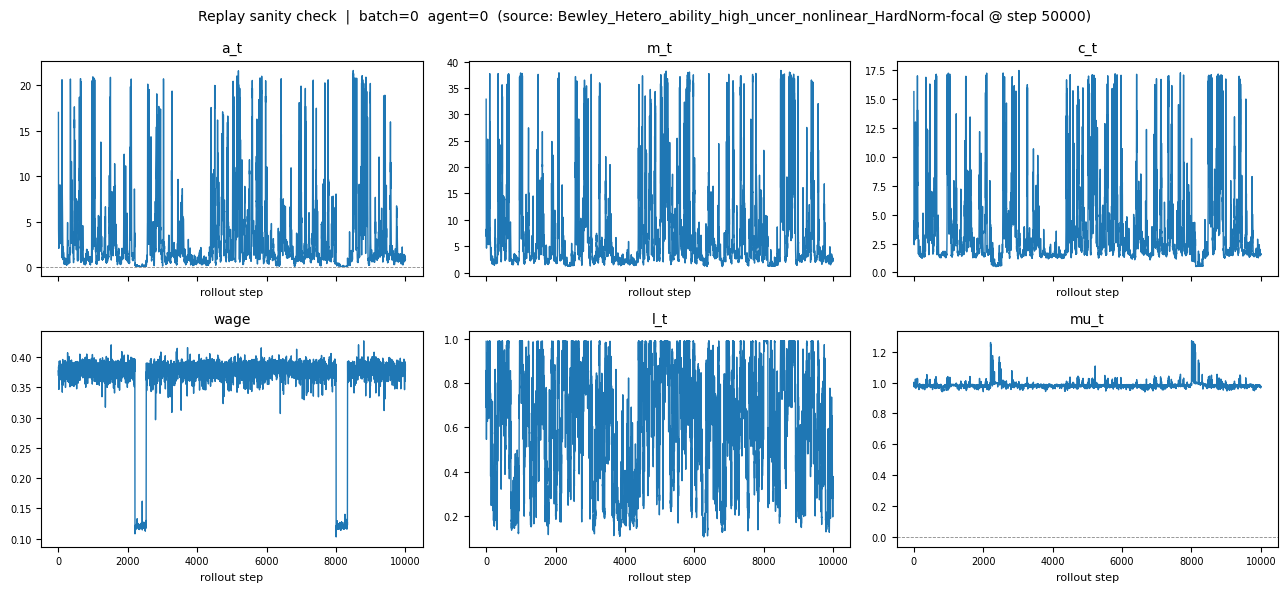

In [7]:
# ── Sanity check: plot a few series from one (batch, agent) ─────────────────
import matplotlib.pyplot as plt

PLOT_BATCH, PLOT_AGENT = 0, 0

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True)
panels = [
    ('a_t',     0, 'y=0'),
    ('m_t',     1, None),
    ('c_t',     4, None),
    ('wage',   10, None),
    ('l_t',    12, None),
    ('mu_t',    7, 'y=0'),
]
for ax, (name, idx, ref) in zip(axes.flat, panels):
    series = sim_data[:, PLOT_BATCH, PLOT_AGENT, idx]
    ax.plot(sim_steps, series, lw=1.0)
    if ref == 'y=0':
        ax.axhline(0, color='#888', lw=0.6, ls='--')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('rollout step', fontsize=8)
    ax.tick_params(labelsize=7)
fig.suptitle(f'Replay sanity check  |  batch={PLOT_BATCH}  agent={PLOT_AGENT}  '
             f'(source: {os.path.basename(CHECKPOINT_DIR)} @ step {SOURCE_STEP})', fontsize=10)
plt.tight_layout()
plt.show()

In [8]:
# ── How to load the saved data later ────────────────────────────────────────
# arr = np.load(data_path)
# data       = arr['data']        # (n_steps, B, A, n_vars)
# steps      = arr['steps']       # (n_steps,)
# var_names  = arr['var_names']   # (n_vars,) string array
# with open(os.path.join(out_subdir, 'meta.pkl'), 'rb') as f:
#     meta = pickle.load(f)